In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

def cnn_estimator_past(data, N_remove, N_estimate, link, normalize_data=True, epochs=50, batch_size=32, save_figures=False, save_path=None, show_figs=False):
    print(f'Estimating for link {link}')

    # Extract the error values and new features
    dates = data['Date']
    # Feature engineering: Extract day of the week and month from the 'Date' column
    data['DayOfWeek'] = data['Date'].dt.dayofweek  # Monday=0, Sunday=6
    data['Month'] = data['Date'].dt.month  # Extracting month
    
    # Prepare the data for model input (including new features)
    feature_columns = ['Error', 'DayOfWeek', 'Month']
    data_features = data[feature_columns]

    # Normalize data if requested
    if normalize_data:
        scaler = MinMaxScaler(feature_range=(0, 1))
        data_values = scaler.fit_transform(data_features)
    else:
        data_values = data_features.values

    # Number of samples
    N = len(data_values)
    
    # Split the data
    if N_remove == 0:
        past_data_values = data_values
        past_dates = dates
        last_date = past_dates.iloc[-1]
        future_dates = pd.date_range(start=last_date, periods=N_estimate + 1, freq='D')[1:]
    else: 
        past_data_values = data_values[:-N_remove] # All the error values except for the last N_remove days
        future_data_values = data_values[-N_remove:] # The last N_remove error values
        past_dates = dates[:-N_remove] # All the error values except for the last N_remove days
        future_dates = pd.date_range(start=dates.iloc[-N_remove], periods=N_estimate + 1, freq='D')[1:]
    
    # Create sequences for CNN (including all features)
    def create_sequences(data, sequence_length=30):
        sequences = []
        labels = []
        for i in range(sequence_length, len(data)):
            sequences.append(data[i-sequence_length:i])
            labels.append(data[i, 0])  # Predicting the 'Error' value (first column)
        return np.array(sequences), np.array(labels)
    
    sequence_length = 30  # Number of past days to use to predict the next
    X, y = create_sequences(past_data_values, sequence_length)

    # Split into training and testing data
    split = int(0.8 * len(X))  # 80% train, 20% test
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Reshape for CNN (samples, time steps, features)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    model = Sequential()

    # Add the Input layer with the input shape
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

    # Add the rest of the CNN layers
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(1))

    # Compile the model
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=1)

    # Predict past data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Inverse transform if data was normalized
    if normalize_data:
        y_train_pred = scaler.inverse_transform(np.concatenate([y_train_pred, X_train[:, -1, 1:]], axis=1))[:, 0]
        y_test_pred = scaler.inverse_transform(np.concatenate([y_test_pred, X_test[:, -1, 1:]], axis=1))[:, 0]
        y_train = scaler.inverse_transform(np.concatenate([y_train.reshape(-1, 1), X_train[:, -1, 1:]], axis=1))[:, 0]
        y_test = scaler.inverse_transform(np.concatenate([y_test.reshape(-1, 1), X_test[:, -1, 1:]], axis=1))[:, 0]
    else:
        y_train_pred = y_train_pred
        y_test_pred = y_test_pred

    # Generate future predictions
    last_sequence = past_data_values[-sequence_length:].reshape((1, sequence_length, past_data_values.shape[1]))
    future_predictions = []
    
    for _ in range(N_estimate):
        future_pred = model.predict(last_sequence)[0]
        future_predictions.append(future_pred)
        last_sequence = np.append(last_sequence[:, 1:, :], [[np.concatenate([future_pred, [last_sequence[0, -1, 1], last_sequence[0, -1, 2]]])]], axis=1)
    
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    
    # Inverse transform future predictions if data was normalized
    if normalize_data:
        future_predictions = scaler.inverse_transform(np.concatenate([future_predictions, np.zeros((future_predictions.shape[0], 2))], axis=1))[:, 0]

    # Combine train and test predictions
    complete_dates = pd.concat([pd.Series(dates[:-N_remove]), pd.Series(future_dates)])
    complete_estimated_data = np.concatenate([model.predict(X).flatten(), future_predictions.flatten()])

    # Error metrics
    error_of_train_estimation = np.abs(y_train - y_train_pred)
    mean_error_train_estimation = np.mean(error_of_train_estimation)
    std_error_train_estimation = np.std(error_of_train_estimation)
    rmse_error_train_estimation = np.sqrt(mean_squared_error(y_train, y_train_pred))

    error_of_test_estimation = np.abs(y_test - y_test_pred)
    mean_error_test_estimation = np.mean(error_of_test_estimation)
    std_error_test_estimation = np.std(error_of_test_estimation)
    rmse_error_test_estimation = np.sqrt(mean_squared_error(y_test, y_test_pred))

    result = {
        link: {
            "Normalized_data": normalize_data,

            "Complete_dates": complete_dates,
            "Complete_estimated_data": complete_estimated_data.tolist(),
                       
            "Past_dates": dates,
            "Last_date": dates.iloc[-1],
            "Past_data": data['Error'].values.tolist(),

            "Future_dates": future_dates,
            "Future_estimated_data": future_predictions.tolist(),

            "Train_dates": dates[:split + sequence_length],
            "Last_train_date": dates[split + sequence_length - 1],
            "Train_data": y_train.tolist(),
            "Train_estimated_data": y_train_pred.tolist(),

            "Train_estimation_error": error_of_train_estimation.tolist(),
            "Train_mean_estimation_error": mean_error_train_estimation,
            "Train_std_estimation_error": std_error_train_estimation,
            "Train_rmse_estimation_error": rmse_error_train_estimation,

            "Test_dates": dates[split + sequence_length:],
            "Test_data": y_test.tolist(),
            "Test_estimated_data": y_test_pred.tolist(),

            "Test_estimation_error": error_of_test_estimation.tolist(),
            "Test_mean_estimation_error": mean_error_test_estimation,
            "Test_std_estimation_error": std_error_test_estimation,
            "Test_rmse_estimation_error": rmse_error_test_estimation,
        }
    }
    # Plotting
    if show_figs or save_figures:
        plt.figure(figsize=(18, 30))

        # Calculate the common Y-axis limits
        all_data = np.concatenate([
            result[link]['Train_data'],
            result[link]['Train_estimated_data'],
            result[link]['Test_data'],
            result[link]['Test_estimated_data'],
            np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'],
            np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error']
        ])

        y_min, y_max = np.min(all_data)-0.0006, np.max(all_data)+0.0006

        # Train data plot
        plt.subplot(4, 1, 1)
        plt.plot(result[link]['Train_dates'][:len(result[link]['Train_data'])], result[link]['Train_data'], label='Actual Data', color='royalblue')
        plt.plot(result[link]['Train_dates'][:len(result[link]['Train_estimated_data'])], result[link]['Train_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--')
        plt.title(f'CNN\nActual vs Estimated Data (train)')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        # Test data plot
        plt.subplot(4, 1, 2)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], result[link]['Test_data'], label='Actual Data', color='royalblue')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_estimated_data'])], result[link]['Test_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--')
        plt.title(f'Actual vs Estimated Data (test)  RMSE: {result[link]["Test_rmse_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        # Upper and lower bounds for test data
        plt.subplot(4, 1, 3)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'], label='Upper Data Bound', color='teal')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error'], label='Lower Data Bound', color='orchid')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_estimated_data'])], result[link]['Test_estimated_data'], label='Estimated Data', color='chocolate', linestyle='--', marker='o')
        plt.title(f'Bounds of Actual vs Estimated Data (test) std: {result[link]["Test_std_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        plt.tight_layout()
        if save_figures:
            plt.savefig(save_path)

        if show_figs:
            plt.show()

        plt.close()


    return result


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

def cnn_estimator_past(data, N_remove, N_estimate, link, normalize_data=True, epochs=50, batch_size=32, save_figures=False, save_path=None, show_figs=False):
    print(f'Estimating for link {link}')

    # Extract the error values and new features
    dates = data['Date']
    # Feature engineering: Extract day of the week and month from the 'Date' column
    data['DayOfWeek'] = data['Date'].dt.dayofweek  # Monday=0, Sunday=6
    data['Month'] = data['Date'].dt.month  # Extracting month
    
    # Prepare the data for model input (including new features)
    feature_columns = ['Error', 'DayOfWeek', 'Month']
    data_features = data[feature_columns]

    # Normalize data if requested
    if normalize_data:
        scaler = MinMaxScaler(feature_range=(0, 1))
        data_values = scaler.fit_transform(data_features)
    else:
        data_values = data_features.values

    # Number of samples
    N = len(data_values)
    
    # Split the data
    if N_remove == 0:
        past_data_values = data_values
        past_dates = dates
        last_date = past_dates.iloc[-1]
        future_dates = pd.date_range(start=last_date, periods=N_estimate + 1, freq='D')[1:]
    else: 
        past_data_values = data_values[:-N_remove] # All the error values except for the last N_remove days
        future_data_values = data_values[-N_remove:] # The last N_remove error values
        past_dates = dates[:-N_remove] # All the error values except for the last N_remove days
        future_dates = pd.date_range(start=dates.iloc[-N_remove], periods=N_estimate + 1, freq='D')[1:]
        last_date = past_dates.iloc[-1]

    print(len(past_dates))
    
    sequence_length = 10 
    # Create sequences for CNN (including all features)
    def create_sequences(data, sequence_length):
        sequences = []
        labels = []
        for i in range(sequence_length, len(data)):
            sequences.append(data[i-sequence_length:i])
            labels.append(data[i, 0])  # Predicting the 'Error' value (first column)
        return np.array(sequences), np.array(labels)
    
     # Number of past days to use to predict the next
    X, y = create_sequences(past_data_values, sequence_length)

    # Split into training and testing data
    X_train, X_test = X[:-N_remove], X[-N_remove:]
    y_train, y_test = y[:-N_remove], y[-N_remove:]

    # Reshape for CNN (samples, time steps, features)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    model = Sequential()

    # Add the Input layer with the input shape
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

    # Add the rest of the CNN layers
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(1))

    # Compile the model
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')

    # Train the model
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

    # Predict past data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Inverse transform if data was normalized
    if normalize_data:
        y_train_pred = scaler.inverse_transform(np.concatenate([y_train_pred, X_train[:, -1, 1:]], axis=1))[:, 0]
        y_test_pred = scaler.inverse_transform(np.concatenate([y_test_pred, X_test[:, -1, 1:]], axis=1))[:, 0]
        y_train = scaler.inverse_transform(np.concatenate([y_train.reshape(-1, 1), X_train[:, -1, 1:]], axis=1))[:, 0]
        y_test = scaler.inverse_transform(np.concatenate([y_test.reshape(-1, 1), X_test[:, -1, 1:]], axis=1))[:, 0]
    else:
        y_train_pred = y_train_pred
        y_test_pred = y_test_pred
    
    # Generate future predictions
    last_sequence = past_data_values[-sequence_length:].reshape((1, sequence_length, past_data_values.shape[1]))
    future_predictions = []
    
    for _ in range(N_estimate):
        future_pred = model.predict(last_sequence)[0]
        future_predictions.append(future_pred)
        last_sequence = np.append(last_sequence[:, 1:, :], [[np.concatenate([future_pred, [last_sequence[0, -1, 1], last_sequence[0, -1, 2]]])]], axis=1)
    
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    
    # Inverse transform future predictions if data was normalized
    if normalize_data:
        future_predictions = scaler.inverse_transform(np.concatenate([future_predictions, np.zeros((future_predictions.shape[0], 2))], axis=1))[:, 0]

    # Combine train and test predictions
    complete_dates = pd.concat([pd.Series(dates[:-N_remove]), pd.Series(future_dates)])
    complete_estimated_data = np.concatenate([model.predict(X).flatten(), future_predictions.flatten()])

    # Error metrics
    error_of_train_estimation = np.abs(y_train - y_train_pred)
    mean_error_train_estimation = np.mean(error_of_train_estimation)
    std_error_train_estimation = np.std(error_of_train_estimation)
    rmse_error_train_estimation = np.sqrt(mean_squared_error(y_train, y_train_pred))

    error_of_test_estimation = np.abs(y_test - y_test_pred)
    mean_error_test_estimation = np.mean(error_of_test_estimation)
    std_error_test_estimation = np.std(error_of_test_estimation)
    rmse_error_test_estimation = np.sqrt(mean_squared_error(y_test, y_test_pred))

    result = {
        link: {
            "Normalized_data": normalize_data,

            "Complete_dates": complete_dates,
            "Complete_estimated_data": complete_estimated_data.tolist(),
                       
            "Past_dates": dates,
            "Last_date": dates.iloc[-1],
            "Past_data": data['Error'].values.tolist(),

            "Future_dates": future_dates,
            "Future_estimated_data": future_predictions.tolist(),

            "Train_dates": past_dates,
            "Last_train_date": last_date,
            "Train_data": y_train.tolist(),
            "Train_estimated_data": y_train_pred.tolist(),

            "Train_estimation_error": error_of_train_estimation.tolist(),
            "Train_mean_estimation_error": mean_error_train_estimation,
            "Train_std_estimation_error": std_error_train_estimation,
            "Train_rmse_estimation_error": rmse_error_train_estimation,

            "Test_dates": future_dates,
            "Test_data": y_test.tolist(),
            "Test_estimated_data": y_test_pred.tolist(),

            "Test_estimation_error": error_of_test_estimation.tolist(),
            "Test_mean_estimation_error": mean_error_test_estimation,
            "Test_std_estimation_error": std_error_test_estimation,
            "Test_rmse_estimation_error": rmse_error_test_estimation,
        }
    }
    
    # Plotting
    if show_figs or save_figures:
        plt.figure(figsize=(18, 30))

        # Calculate the common Y-axis limits
        all_data = np.concatenate([
            result[link]['Train_data'],
            result[link]['Train_estimated_data'],
            result[link]['Test_data'],
            result[link]['Test_estimated_data'],
            np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'],
            np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error'],
            result[link]['Test_estimation_error']
        ])

        y_min, y_max = np.min(all_data)-0.0006, np.max(all_data)+0.0006

        # Train data plot
        plt.subplot(4, 1, 1)
        plt.plot(result[link]['Test_dates'], result[link]['Test_data'], label='Actual Data', color='royalblue',  marker='o')
        plt.plot(result[link]['Test_dates'], result[link]['Test_estimated_data'], label='Estimated Data', color='darkorange', linestyle='--',  marker='x')
        plt.title(f'CNN\nActual vs Estimated Data (train)')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        # Test data plot
        plt.subplot(4, 1, 2)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], result[link]['Test_estimation_error'], label='Error of the Estimation', color='green', marker='o')
        plt.axhline(result[link]['Test_mean_estimation_error'], linestyle='dashed', label='Average Estimation Error', color='purple')
        plt.axhline(result[link]['Test_rmse_estimation_error'], linestyle='dashed', label='Root Mean Squared Error', color='deeppink')
        plt.title(f'Actual vs Estimated Data (test)  RMSE: {result[link]["Test_rmse_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        # Upper and lower bounds for test data
        plt.subplot(4, 1, 3)
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) + result[link]['Test_mean_estimation_error'], label='Upper Data Bound', color='teal', marker='o')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_data'])], np.array(result[link]['Test_data']) - result[link]['Test_mean_estimation_error'], label='Lower Data Bound', color='orchid', marker='o')
        plt.plot(result[link]['Test_dates'][:len(result[link]['Test_estimated_data'])], result[link]['Test_estimated_data'], label='Estimated Data', color='chocolate', linestyle='--', marker='x')
        plt.title(f'Bounds of Actual vs Estimated Data (test) std: {result[link]["Test_std_estimation_error"]}')
        plt.xlabel('Date')
        plt.ylabel('Error')
        plt.legend()
        plt.grid()
        plt.ylim(y_min, y_max)  # Set common Y-axis limits

        plt.tight_layout()
        if save_figures:
            plt.savefig(save_path)

        if show_figs:
            plt.show()

        plt.close()


    result[link]["Complete_dates"] = result[link]["Complete_dates"].to_list()
    result[link]["Train_dates"] = result[link]["Train_dates"].to_list()
    result[link]["Test_dates"] = result[link]["Test_dates"].to_list()
    result[link]["Past_dates"] = result[link]["Past_dates"].to_list()
    
    for key in result:
        result[key]['Complete_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Complete_dates']]
        result[key]['Train_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Train_dates']]
        result[key]['Test_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Test_dates']]
        result[key]['Past_dates'] = [date.strftime('%Y-%m-%d') for date in result[key]['Past_dates']]
        result[key]['Last_date'] = result[key]['Last_date'].strftime('%Y-%m-%d')
        result[key]['Last_train_date'] = result[key]['Last_train_date'].strftime('%Y-%m-%d')

    
    return result


Estimating for link 0-14
190
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0496  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0278 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0226 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0282 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0270 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 0.0289  
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0296 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0203 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0264 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0165 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 0.0266
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - loss: 0.0211
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0175 
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0195 
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 654us/step -

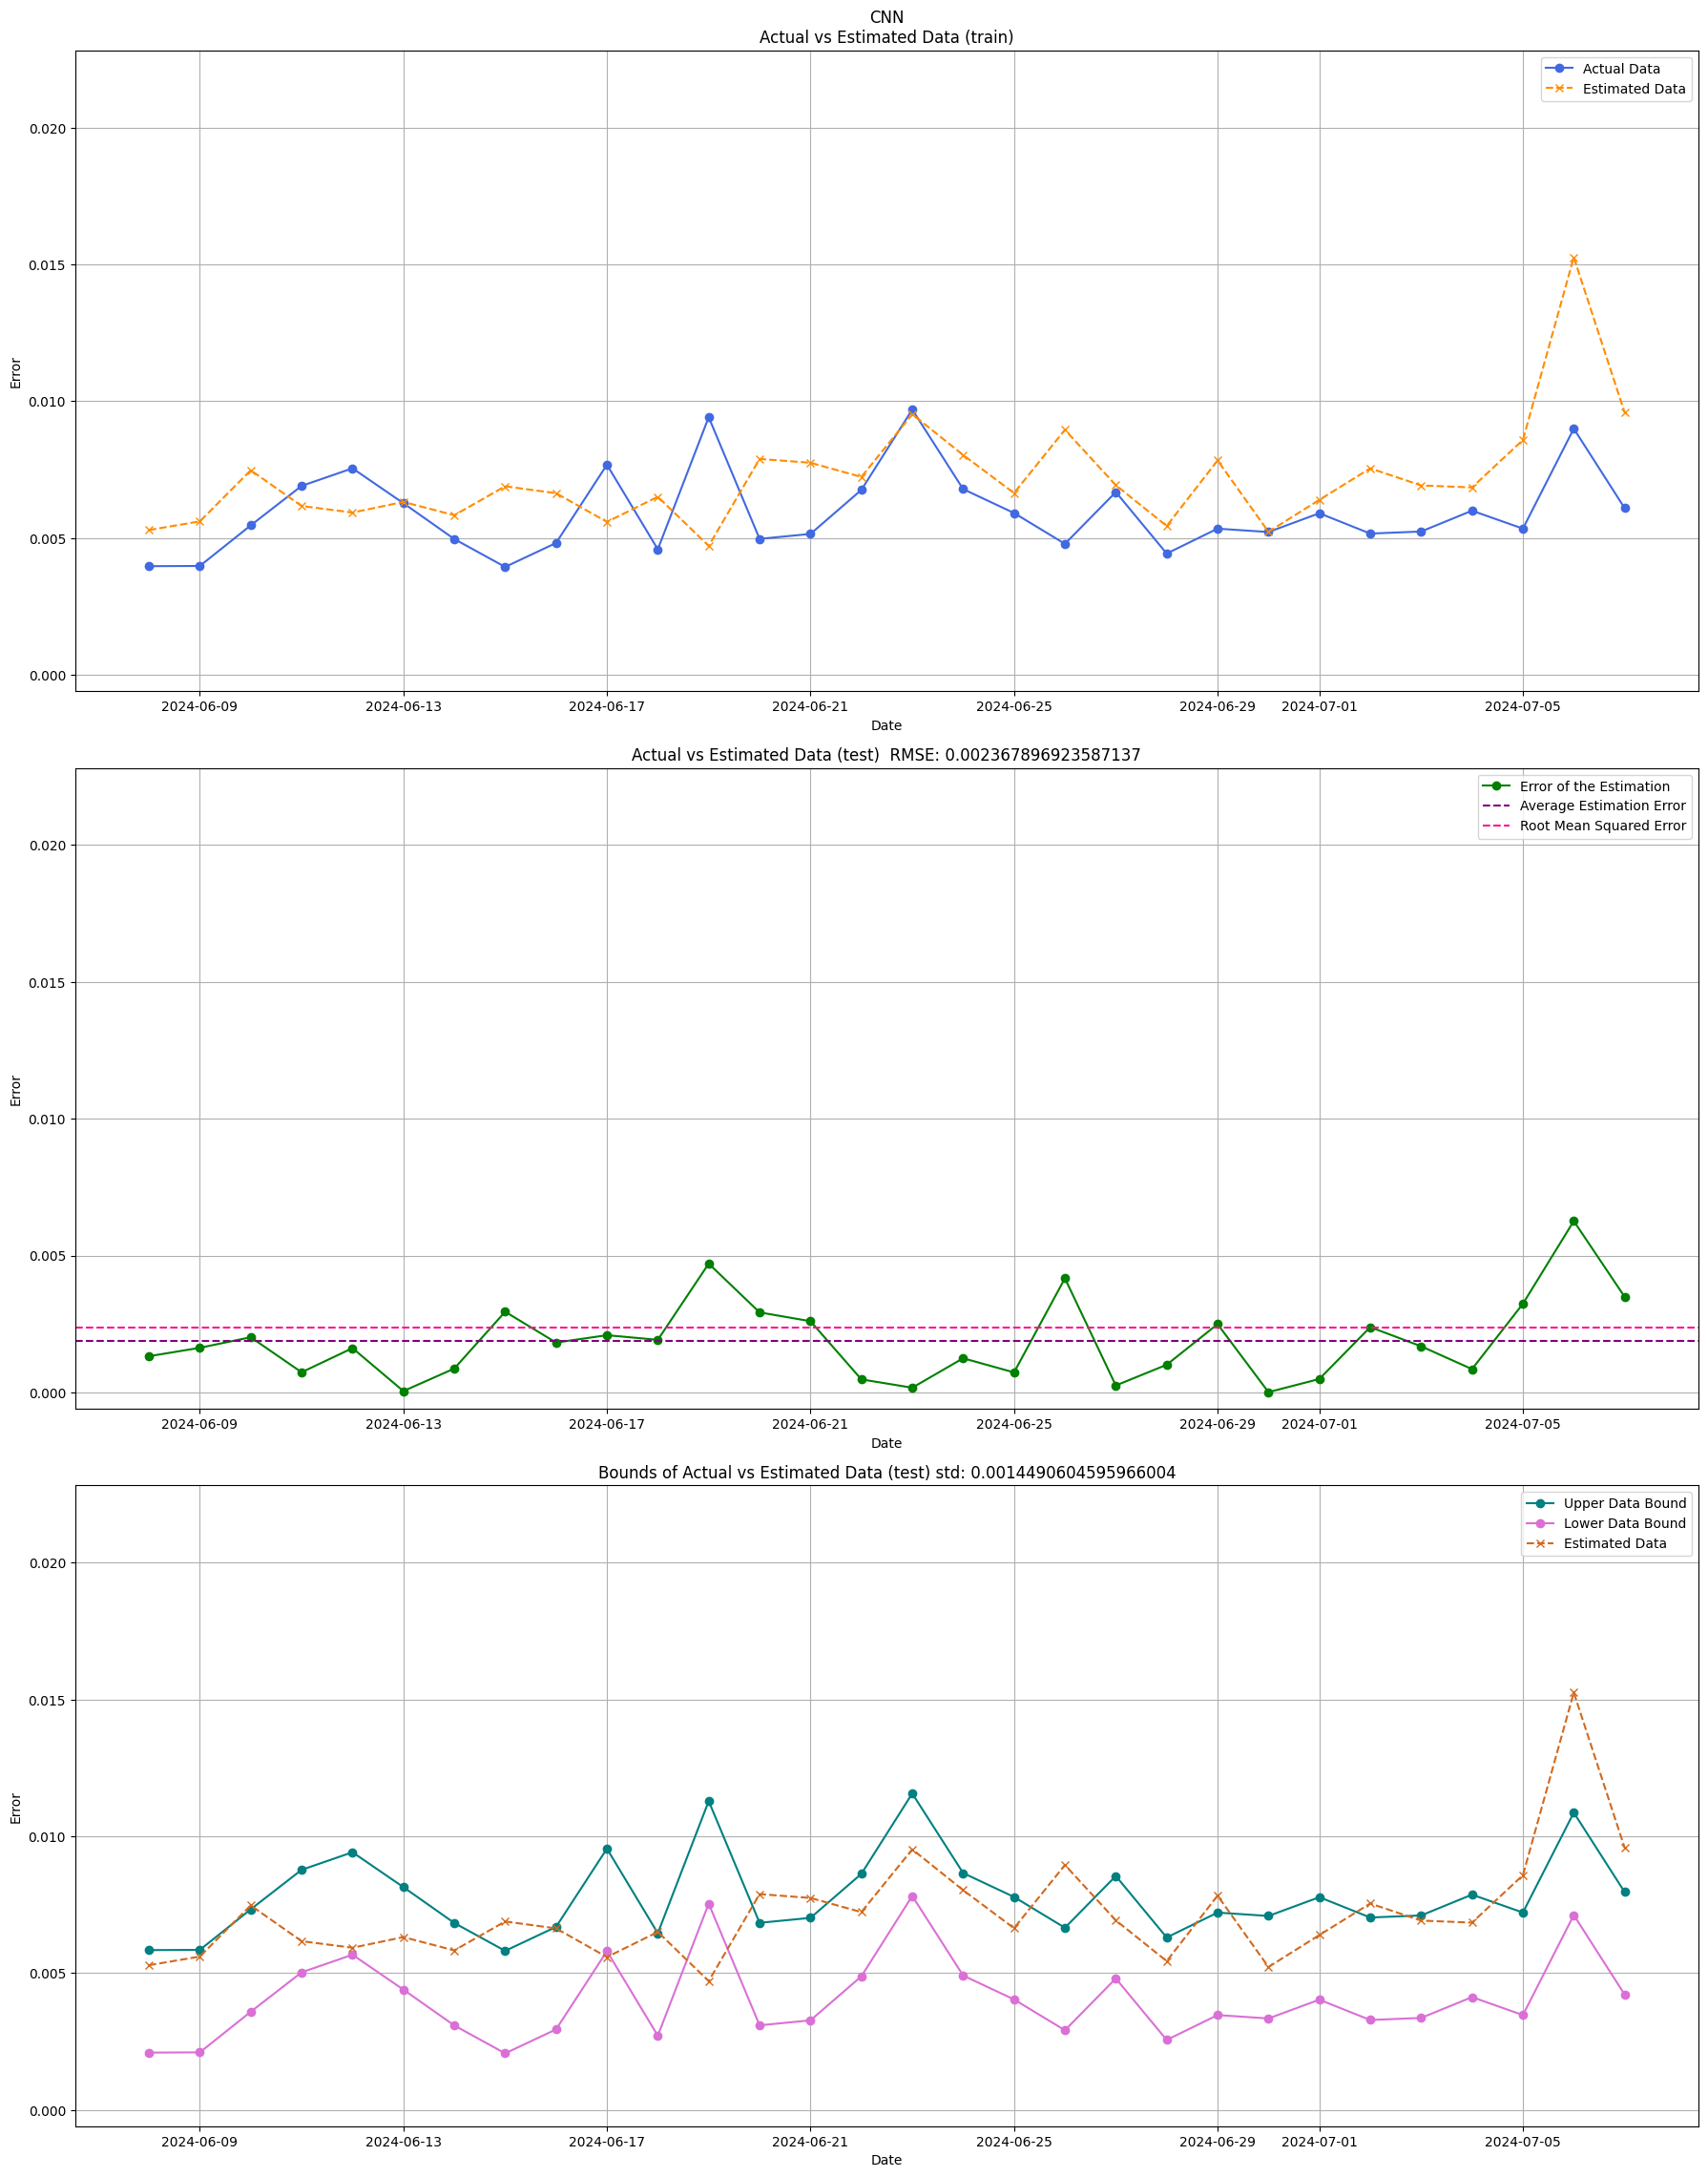

{'0-14': {'Normalized_data': True,
  'Complete_dates': ['2023-10-31',
   '2023-11-01',
   '2023-11-02',
   '2023-11-03',
   '2023-11-04',
   '2023-11-05',
   '2023-11-06',
   '2023-11-07',
   '2023-11-08',
   '2023-11-09',
   '2023-11-10',
   '2023-11-11',
   '2023-11-12',
   '2023-11-13',
   '2023-11-14',
   '2023-11-15',
   '2023-11-16',
   '2023-11-17',
   '2023-11-18',
   '2023-11-19',
   '2023-11-20',
   '2023-11-21',
   '2023-11-22',
   '2023-11-23',
   '2023-11-24',
   '2023-11-25',
   '2023-11-26',
   '2023-11-27',
   '2023-11-28',
   '2023-11-29',
   '2023-11-30',
   '2023-12-01',
   '2023-12-02',
   '2023-12-03',
   '2023-12-04',
   '2023-12-05',
   '2023-12-06',
   '2023-12-07',
   '2023-12-08',
   '2023-12-09',
   '2023-12-10',
   '2023-12-11',
   '2023-12-12',
   '2023-12-13',
   '2023-12-14',
   '2023-12-15',
   '2023-12-16',
   '2023-12-17',
   '2023-12-18',
   '2023-12-19',
   '2023-12-20',
   '2023-12-21',
   '2023-12-22',
   '2023-12-23',
   '2023-12-24',
   '2023-12-

: 

In [33]:
file_path = 'up_to_15-07-2024/brisbane_0-14.xlsx'  # Update this path to the correct location of your Excel file
df = pd.read_excel(file_path)
cnn_estimator_past(df, 30, 30, '0-14', normalize_data=True, epochs=100, save_figures=False, save_path=None, show_figs=True)